In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import scipy.stats as stats

df = pd.read_csv('../02_Datasets/processed/youtube_influencers_clean.csv')
df = df[df['subscribers'] >= 100].copy()
df = df[df['view_per_subscriber'] > 0].copy()
print(df.shape)
print(df.columns.tolist())

(5376, 10)
['channel_name', 'channel_id', 'subscribers', 'total_views', 'video_count', 'avg_views_per_video', 'view_per_subscriber', 'country', 'tier', 'niche']


In [4]:
df['log_subscribers'] = np.log10(df['subscribers'])
df['log_vps'] = np.log10(df['view_per_subscriber'])

In [5]:
X = df[['log_subscribers']]
y = df['log_vps']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"R² = {r2:.4f}")
print(f"Coefficient = {model.coef_[0]:.4f}")
print(f"Intercept = {model.intercept_:.4f}")
print(f"\nInterpretation: For every 10x increase in subscribers,")
print(f"engagement changes by {model.coef_[0]:.2f} on the log scale")

R² = 0.2688
Coefficient = -0.2315
Intercept = 0.9740

Interpretation: For every 10x increase in subscribers,
engagement changes by -0.23 on the log scale


In [6]:
corr, pval = stats.pearsonr(df['log_subscribers'], df['log_vps'])
print(f"\nCorrelation: {corr:.4f}")
print(f"P-value: {pval:.2e}")


Correlation: -0.5184
P-value: 0.00e+00


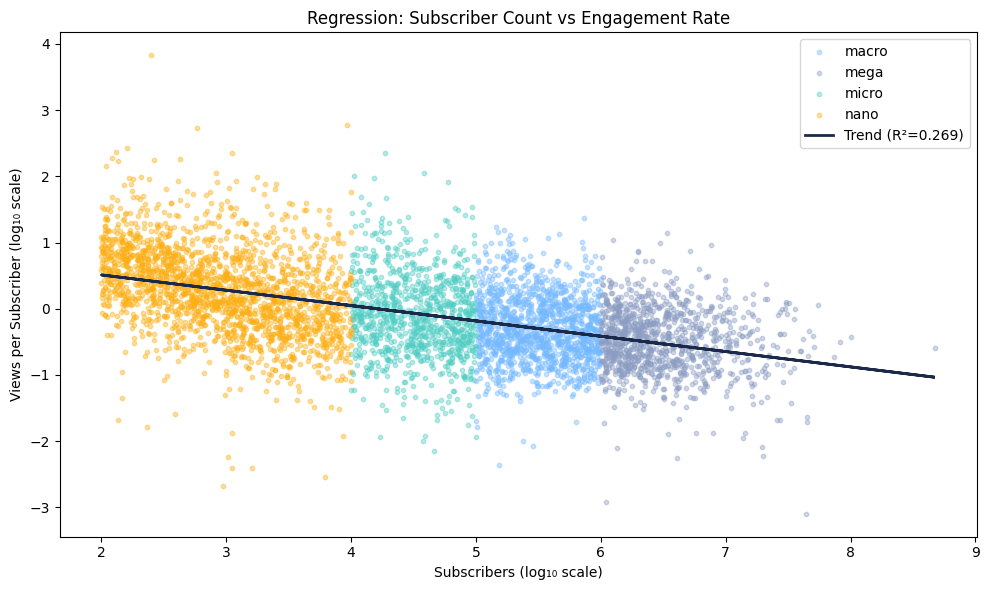

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'nano': '#fcae12', 'micro': '#4ECDC4', 'macro': '#74B9FF', 'mega': '#8B9DC3'}
for tier, group in df.groupby('tier'):
    ax.scatter(group['log_subscribers'], group['log_vps'],
               c=colors[tier], label=tier, alpha=0.4, s=10)

ax.plot(X, y_pred, color='#1B2A4A', linewidth=2, label=f'Trend (R²={r2:.3f})')

ax.set_xlabel('Subscribers (log₁₀ scale)')
ax.set_ylabel('Views per Subscriber (log₁₀ scale)')
ax.set_title('Regression: Subscriber Count vs Engagement Rate')
ax.legend()
plt.tight_layout()
plt.savefig('regression_h3.png', dpi=150)
plt.show()

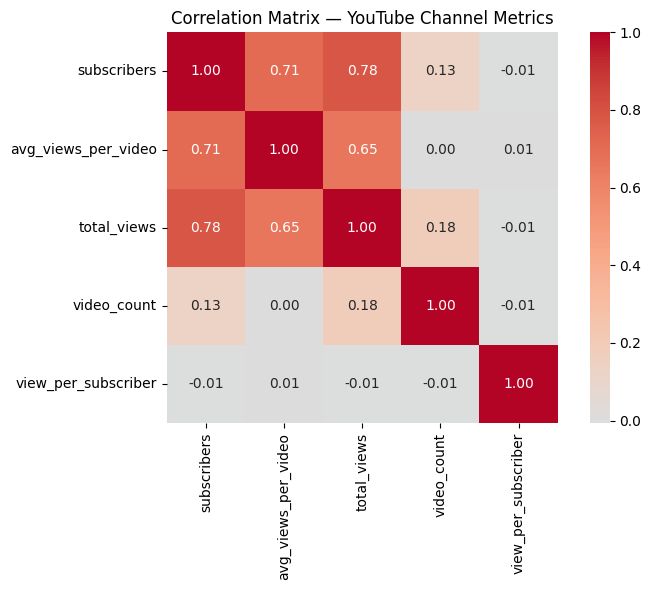

In [8]:
numeric_cols = ['subscribers', 'avg_views_per_video', 'total_views', 
                'video_count', 'view_per_subscriber']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Correlation Matrix — YouTube Channel Metrics')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

##### ─── CORRELATION MATRIX FINDINGS ──────────────────────────────────
##### subscribers ↔ avg_views_per_video : r = 0.71  → size drives raw view volume
##### subscribers ↔ total_views         : r = 0.78  → size drives total reach
##### video_count ↔ all metrics         : r ≈ 0.00  → posting frequency does NOT
#                                                   predict performance
##### view_per_subscriber ↔ all metrics : r ≈ -0.01 → engagement rate is INDEPENDENT
#####                                                  of size, volume, and frequency
#
##### Implication: engagement rate is a unique channel quality —
##### nano influencers excel at it regardless of their size.

### ─── REGRESSION FINDINGS ───────────────────────────────────────────
### H3 CONFIRMED: Smaller channels produce more views per subscriber
###
#### Pearson r  = -0.52  →  moderate-strong negative relationship
#### P-value    ≈ 0.00   →  statistically significant (p < 0.001)
#### R²         = 0.27   →  subscriber count explains 27% of engagement variance
#### Coefficient = -0.23 →  every 10× increase in subscribers = ~41% drop in engagement
####
### Implication for brands:
#### Nano influencers (1K–10K subscribers) deliver significantly higher engagement per subscriber than mega influencers (1M+).
#### A brand investing in 10 nano creators will likely outperform one mega creator on engagement metrics.

# Engagement rate is independent of channel size, total views, and content volume — it is a unique quality that nano influencers consistently outperform on.